# Covariates File 
1. Clean up master key
2. Subset to samples kept for analysis
3. Merge PCs and get final counts of samples that have genetic data that passed QC
   - Get case/control distribution per ancestry
   - Get female % case/control per ancestry
4. Determine number of PCs to keep for GWAS 

In [2]:
## Import the necessary packages 
import os
import numpy as np
import pandas as pd
import math
import numbers
import sys
import subprocess
import statsmodels.api as sm
import scipy
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Print out package versions
## Getting packages loaded into this notebook and their versions to allow for reproducibility
    # Repurposed code from stackoverflow here: https://stackoverflow.com/questions/40428931/package-for-listing-version-of-packages-used-in-a-jupyter-notebook

## Import packages 
import pkg_resources
import types
from datetime import date
today = date.today()
date = today.strftime("%d-%b-%Y").upper()

## Define function 
def get_imports():
    for name, val in globals().items():
        if isinstance(val, types.ModuleType):
            # Split ensures you get root package, not just imported function
            name = val.__name__.split(".")[0]

        elif isinstance(val, type):
            name = val.__module__.split(".")[0]

        # Some packages are weird and have different imported names vs. system/pip names
        # Unfortunately, there is no systematic way to get pip names from a package's imported name. You'll have to add exceptions to this list manually!
        poorly_named_packages = {
            "PIL": "Pillow",
            "sklearn": "scikit-learn"
        }
        if name in poorly_named_packages.keys():
            name = poorly_named_packages[name]

        yield name

## Get a list of packages imported 
imports = list(set(get_imports()))

# The only way I found to get the version of the root package from only the name of the package is to cross-check the names of installed packages vs. imported packages
requirements = []
for m in pkg_resources.working_set:
    if m.project_name in imports and m.project_name!="pip":
        requirements.append((m.project_name, m.version))

## Print out packages and versions 
print(f"PACKAGE VERSIONS ({date})")
for r in requirements:
    print("\t{}=={}".format(*r))

PACKAGE VERSIONS (20-NOV-2025)
	seaborn==0.13.2
	statsmodels==0.14.4
	matplotlib==3.7.2
	numpy==1.24.4
	pandas==2.0.3
	scipy==1.11.1


In [3]:
def missingness_percentage(df):
    # Calculate the percentage of missing values per column
    percent_missing = df.isnull().mean() * 100
    # Sort the percentage of missing values in descending order
    percent_missing = percent_missing.sort_values(ascending=False)
    # Convert the result to a dataframe and return it
    return pd.DataFrame({'Column': percent_missing.index, 'Percent_missing': percent_missing.values})

# Clean up masterkey

In [ ]:
key = pd.read_csv(f'{DATA_DIR}/GP2_R11/master_key_release11_final_vwb_12_11_25.csv', low_memory=False)
key

In [ ]:
## Keep only unrelated individuals 
toKeep = pd.read_csv(f'{DATA_DIR}/GP2_R11/sampleIDs_toKeep_noRelateds.txt', sep = '\t', header = None)
toKeep.columns = ['FID', 'GP2sampleID']
toKeep

In [ ]:
subset_key = key[key['GP2ID'].isin(toKeep['GP2sampleID'])].copy()
subset_key.to_csv(f'{DATA_DIR}/GP2_R11/full_key_AFR_AAC_noRelateds.tsv', sep = '\t', index = False)
subset_key

In [20]:
subset_key.columns

Index(['study', 'GP2ID', 'GP2sampleID', 'nba', 'wgs', 'clinical_exome',
       'extended_clinical_data', 'nba_prune_reason', 'wgs_prune_reason',
       'nba_label', 'wgs_label', 'SentrixBarcode_A', 'SentrixPosition_A',
       'related', 'nba_duplicate', 'sample_id', 'clinical_id', 'study_arm',
       'study_type', 'diagnosis', 'GP2_PHENO', 'GP2_phenotype',
       'GP2_phenotype_for_qc', 'SampleRepNo', 'race_for_qc',
       'family_history_for_qc', 'region_for_qc', 'biological_sex_for_qc',
       'manifest_id', 'Genotyping_site', 'alternative_id1', 'alternative_id2',
       'sample_type', 'DNA_volume', 'DNA_conc', 'r260_280', 'Plate_name',
       'Plate_position', 'sex', 'race', 'age', 'age_of_onset',
       'age_at_diagnosis', 'age_at_death', 'age_at_last_follow_up', 'region',
       'comment', 'manifest', 'family_history_details', 'family_history_other',
       'family_history_pd', 'family_index', 'family_index_relationship',
       'GDPR', 'FID', 'amppd_wgs', 'flag'],
      dtype='ob

In [ ]:
columns_toKeep = ['GP2ID', 'GP2_PHENO', 'GP2_phenotype_for_qc', 'biological_sex_for_qc', 'nba_label', 
                  'study', 'clinical_id', 'family_history_for_qc', 
                  'age', 'age_of_onset', 'age_at_diagnosis', 'age_at_death', 'age_at_last_follow_up', 'region']

subset_key = subset_key[columns_toKeep].copy()
subset_key.to_csv(f'{DATA_DIR}/GP2_R11/subset_key_AFR_AAC_noRelateds.tsv', sep = '\t', index = False)
subset_key

### Add PLINK sex and pheno encoding

In [23]:
# PLINK_SEX (1 = Male, 2 = Female)
subset_key['PLINK_SEX'] = subset_key['biological_sex_for_qc'].map({'Male': 1,'Female': 2}).fillna(-9).astype(int)

# PLINK_PHENO (1 = Control, 2 = Case)
subset_key['PLINK_PHENO'] = subset_key['GP2_phenotype_for_qc'].map({'Control': 1,'PD': 2}).fillna(-9).astype(int)

## Subset to keep only cases and controls (no other phenotypes or prodromals)

In [ ]:
subset_cc = subset_key[subset_key['GP2_phenotype_for_qc'] != 'Other'].copy()
subset_cc

In [27]:
missingness_percentage(subset_cc)

,Column,Percent_missing
0,age_at_death,99.850131
1,age_at_diagnosis,92.581491
2,age_at_last_follow_up,77.045086
3,age_of_onset,66.267016
4,region,22.967404
5,age,3.684276
6,GP2ID,0.000000
7,GP2_PHENO,0.000000
8,GP2_phenotype_for_qc,0.000000
9,biological_sex_for_qc,0.000000


In [ ]:
subset_cc

## Make PLINK helper files

In [29]:
## Make new toKeep file (no relateds, only case/controls AFR and AAC) to make new PCs 
samples_toKeep = subset_cc[['GP2ID', 'GP2ID']].copy()
samples_toKeep.columns = ['FID', 'IID']
samples_toKeep.to_csv(f'{DATA_DIR}/GP2_R11/sampleIDs_toKeep_noRelateds_CC.txt', sep = '\t', index = False, header = False)

In [30]:
## Make files to update in PLINK
pheno_toUpdate = subset_cc[['GP2ID', 'GP2ID', 'PLINK_PHENO']].copy()
pheno_toUpdate.columns = ['FID', 'IID', 'pheno']
pheno_toUpdate.to_csv(f'{DATA_DIR}/GP2_R11/pheno_toUpdate_AFR_AAC_noRelateds_CC.txt', sep = '\t', index = False, header = False)

sex_toUpdate = subset_cc[['GP2ID', 'GP2ID','PLINK_SEX']].copy()
sex_toUpdate.columns = ['FID', 'IID', 'sex']
sex_toUpdate.to_csv(f'{DATA_DIR}/GP2_R11/sex_toUpdate_AFR_AAC_noRelateds_CC.txt', sep = '\t', index = False, header = False)

# Merge PCs to covariates

In [ ]:
pca_AFR = pd.read_csv(f'{DATA_DIR}/GP2_R11/raw_genotypes/AFR/pcs.GP2_R11_AFR.PCA.txt', sep = '\t')
pca_AAC = pd.read_csv(f'{DATA_DIR}/GP2_R11/raw_genotypes/AAC/pcs.GP2_R11_AAC.PCA.txt', sep = '\t')

all_PCs = pd.concat([pca_AFR, pca_AAC], ignore_index=True)
all_PCs.drop(columns = ['FID'], inplace = True)
all_PCs

In [ ]:
covs = subset_cc[['GP2ID','GP2ID', 'PLINK_PHENO', 'PLINK_SEX', 'nba_label']].copy()
covs.columns = ['FID','IID', 'PHENO', 'SEX', 'LABEL']
merged_covs = pd.merge(covs, all_PCs, on='IID', how='left')

# Drop rows where ANY PC is missing
pc_cols = [col for col in merged_covs.columns if col.startswith("PC")]
merged_covs = merged_covs.dropna(subset=pc_cols, how='any')

# save
merged_covs.to_csv(f'{DATA_DIR}/GP2_R11/GP2_R11_AFR_AAC_covariates_noRelateds_CC_PCs.tsv', sep = '\t', index = False)
merged_covs

In [36]:
merged_covs.groupby(["LABEL", "PHENO"])["IID"].nunique().reset_index(name="count")

,LABEL,PHENO,count
0,AAC,1,807
1,AAC,2,472
2,AFR,1,4198
3,AFR,2,2504


In [38]:
# Count sex distribution per group
sex_counts = merged_covs.groupby(["LABEL", "PHENO", "SEX"])["IID"].nunique().reset_index(name="sex_count")

# Total per group
total_counts = sex_counts.groupby(["LABEL", "PHENO"])["sex_count"].sum().reset_index(name="total")

# Merge and compute percentage
sex_percent = sex_counts.merge(total_counts, on=["LABEL", "PHENO"])
sex_percent["percent"] = (sex_percent["sex_count"] / sex_percent["total"]) * 100

# Optional: pivot for prettier display
sex_percent_pivot = sex_percent.pivot_table(
    index=["LABEL", "PHENO"],
    columns="SEX",
    values="percent"
).reset_index().rename(columns={1: "% Male", 2: "% Female"})

print(sex_percent_pivot)

SEX LABEL  PHENO     % Male   % Female
0     AAC      1  36.183395  63.816605
1     AAC      2  60.593220  39.406780
2     AFR      1  51.572177  48.427823
3     AFR      2  69.648562  30.351438


## Determine number of PCs to use


===== PCA Variance Table =====

    eigenvalue  variance_explained  cumulative_variance
PC                                                     
1     3.775467            9.777110             9.777110
2     3.372411            8.733339            18.510449
3     2.711492            7.021795            25.532243
4     2.344946            6.072572            31.604815
5     2.209012            5.720551            37.325366
6     1.820139            4.713509            42.038876
7     1.804266            4.672404            46.711280
8     1.778038            4.604483            51.315762
9     1.697980            4.397161            55.712924
10    1.663853            4.308784            60.021708
11    1.646365            4.263497            64.285205
12    1.632040            4.226400            68.511605
13    1.565071            4.052974            72.564579
14    1.563241            4.048235            76.612814
15    1.549259            4.012027            80.624841
16    1.522537 

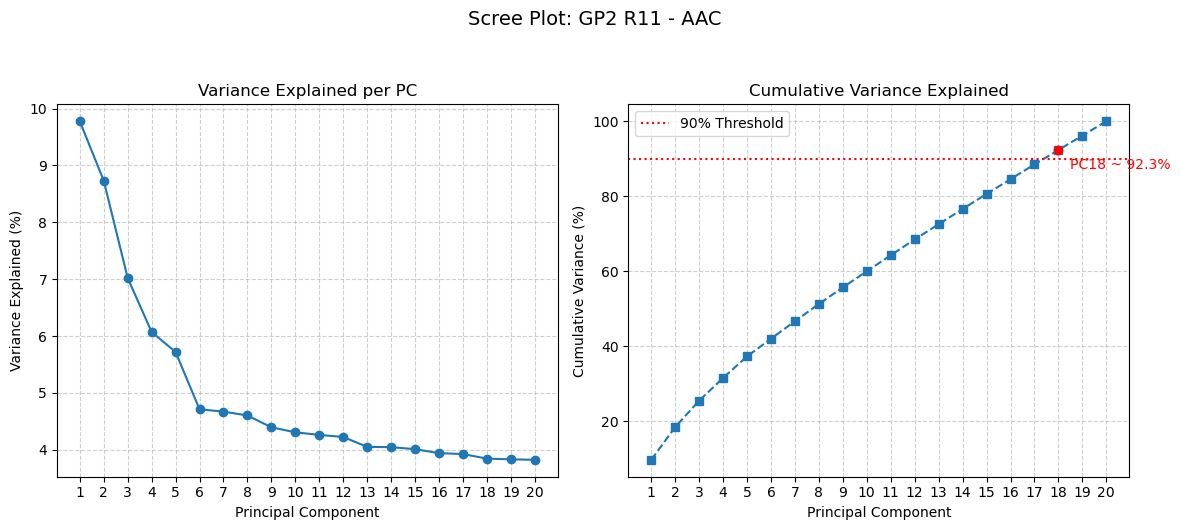

In [68]:
eigenval_file = f"{DATA_DIR}/GP2_R11/raw_genotypes/AAC/eigenvalues.GP2_R11_AAC.PCA.txt"
eigenvals = pd.read_csv(eigenval_file, header=None, names=["eigenvalue"])

eigenvals["variance_explained"] = (
    eigenvals["eigenvalue"] / eigenvals["eigenvalue"].sum() * 100)
eigenvals["cumulative_variance"] = eigenvals["variance_explained"].cumsum()

table = eigenvals.copy()
table.index = table.index + 1        # make PCs start at 1 instead of 0
table.index.name = "PC"

print("\n===== PCA Variance Table =====\n")
print(table.to_string())
pc90 = (eigenvals["cumulative_variance"] >= 90).idxmax() + 1
var90 = eigenvals.loc[pc90 - 1, "cumulative_variance"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Left: Variance explained
axes[0].plot(
    range(1, len(eigenvals) + 1),
    eigenvals["variance_explained"],
    marker="o"
)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Variance Explained per PC")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Right: Cumulative variance explained
axes[1].plot(
    range(1, len(eigenvals) + 1),
    eigenvals["cumulative_variance"],
    marker="s",
    linestyle="--"
)
axes[1].axhline(y=90, color="red", linestyle=":", label="90% Threshold")
axes[1].scatter(pc90, var90, color="red", zorder=5)
axes[1].text(
    pc90 + 0.5,
    var90 - 5,
    f"PC{pc90} ~ {var90:.1f}%",
    color="red"
)
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

axes[0].set_xticks(range(1, len(eigenvals) + 1))
axes[1].set_xticks(range(1, len(eigenvals) + 1))

fig.suptitle("Scree Plot: GP2 R11 - AAC", fontsize=14, y=1.05)

plt.tight_layout()
fig.savefig(f"{DATA_DIR}/GP2_R11/raw_genotypes/AAC/scree_plot_AAC_R11.png", dpi=300, bbox_inches="tight")
plt.show()


===== PCA Variance Table =====

    eigenvalue  variance_explained  cumulative_variance
PC                                                     
1    17.087930           12.590418            12.590418
2    10.306640            7.593951            20.184370
3     9.441413            6.956451            27.140821
4     8.458633            6.232336            33.373157
5     8.259278            6.085451            39.458608
6     7.938725            5.849267            45.307876
7     7.129785            5.253239            50.561114
8     6.934607            5.109431            55.670546
9     6.367539            4.691615            60.362160
10    5.990056            4.413484            64.775645
11    5.982625            4.408009            69.183654
12    5.362431            3.951049            73.134703
13    5.239302            3.860327            76.995030
14    4.935575            3.636541            80.631571
15    4.697149            3.460868            84.092439
16    4.590982 

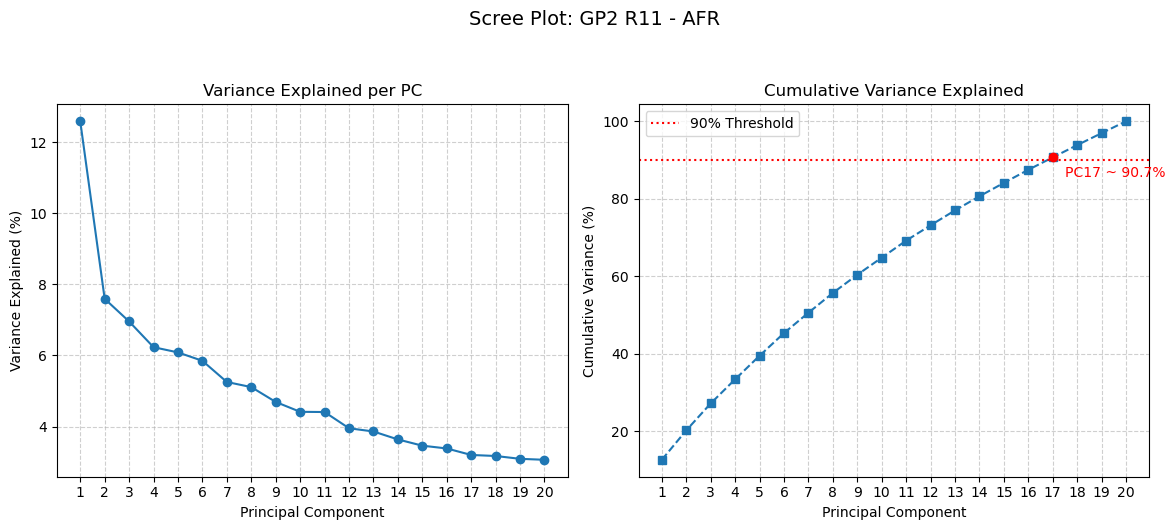

In [9]:
eigenval_file = f"{DATA_DIR}/GP2_R11/raw_genotypes/AFR/eigenvalues.GP2_R11_AFR.PCA.txt"
eigenvals = pd.read_csv(eigenval_file, header=None, names=["eigenvalue"])

eigenvals["variance_explained"] = (
    eigenvals["eigenvalue"] / eigenvals["eigenvalue"].sum() * 100)
eigenvals["cumulative_variance"] = eigenvals["variance_explained"].cumsum()

table = eigenvals.copy()
table.index = table.index + 1        # make PCs start at 1 instead of 0
table.index.name = "PC"

print("\n===== PCA Variance Table =====\n")
print(table.to_string())
pc90 = (eigenvals["cumulative_variance"] >= 90).idxmax() + 1
var90 = eigenvals.loc[pc90 - 1, "cumulative_variance"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Left: Variance explained
axes[0].plot(
    range(1, len(eigenvals) + 1),
    eigenvals["variance_explained"],
    marker="o"
)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Variance Explained per PC")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Right: Cumulative variance explained
axes[1].plot(
    range(1, len(eigenvals) + 1),
    eigenvals["cumulative_variance"],
    marker="s",
    linestyle="--"
)
axes[1].axhline(y=90, color="red", linestyle=":", label="90% Threshold")
axes[1].scatter(pc90, var90, color="red", zorder=5)
axes[1].text(
    pc90 + 0.5,
    var90 - 5,
    f"PC{pc90} ~ {var90:.1f}%",
    color="red"
)
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

axes[0].set_xticks(range(1, len(eigenvals) + 1))
axes[1].set_xticks(range(1, len(eigenvals) + 1))

fig.suptitle("Scree Plot: GP2 R11 - AFR", fontsize=14, y=1.05)

plt.tight_layout()
fig.savefig(f"{DATA_DIR}/GP2_R11/raw_genotypes/AFR/scree_plot_AFR_R11.png", dpi=300, bbox_inches="tight")
plt.show()

## Correlation Matrix

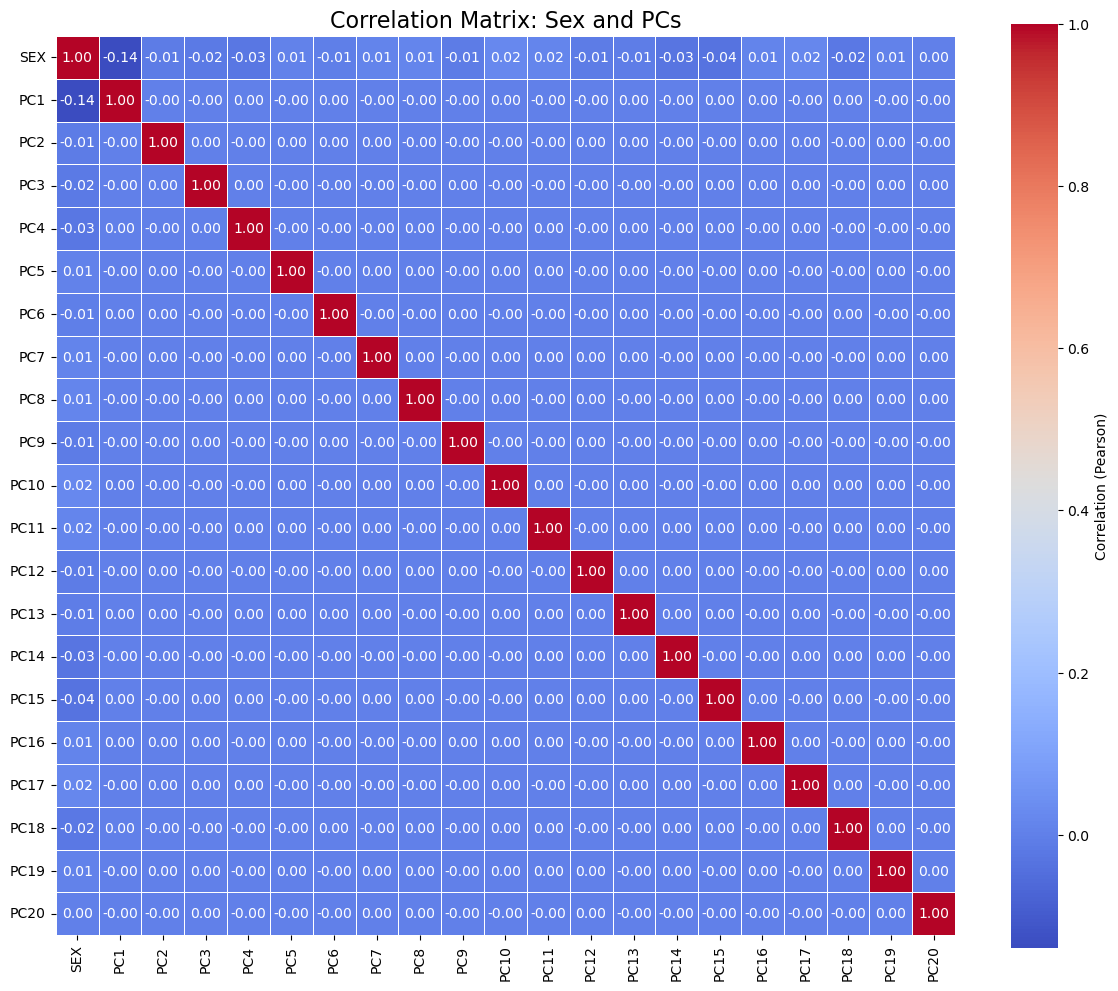

In [33]:
merged_covs = pd.read_csv(f'{DATA_DIR}/GP2_R11/GP2_R11_AFR_AAC_covariates_noRelateds_CC_PCs.tsv', sep = '\t')

sex_col = "SEX"
pc_cols = [col for col in merged_covs.columns if col.startswith("PC")]
cols = [sex_col] + pc_cols
corr_matrix = merged_covs[cols].corr()

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr_matrix,
    annot=True,          # numbers inside boxes
    fmt=".2f",           # 2 decimals
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation (Pearson)"}
)

plt.title("Correlation Matrix: Sex and PCs", fontsize=16)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/GP2_R11/raw_genotypes/corrMatrix.png", dpi=300, bbox_inches="tight")
plt.show()